In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (balanced_accuracy_score, accuracy_score, classification_report, confusion_matrix)

In [4]:
# 1. Load and clean data (EDA)

df = pd.read_csv("train.csv")
df.drop("id", axis=1, inplace=True)
 
num_cols = df.select_dtypes(include="float64").columns
cat_cols = df.select_dtypes(exclude="float64").columns.drop("health_condition")
 
impute_values = {}
for col in num_cols:
    impute_values[col] = df[col].mean()
    df[col] = df[col].fillna(impute_values[col])
 
for col in cat_cols:
    impute_values[col] = df[col].mode()[0]
    df[col] = df[col].fillna(impute_values[col])

In [11]:
df

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,2,5.22,70.6,25.66,2174.0,1326.00000,19.8,1.86,2,0,0,2,2,0
1,0,5.53,71.3,25.84,1966.0,9891.00000,49.9,1.26,1,1,0,1,2,2
2,2,5.29,75.4,24.54,2688.0,14216.00000,38.1,1.60,2,0,2,0,2,1
3,2,4.70,77.2,23.13,2630.0,7174.00000,59.9,2.02,2,0,0,0,1,0
4,0,7.23,73.4,28.44,2560.0,6584.00000,46.0,2.25,2,2,0,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,0,6.31,69.7,24.11,2157.0,8615.95305,30.8,3.00,1,0,2,0,2,0
690084,0,5.78,54.0,26.36,2858.0,6488.00000,52.4,1.46,2,2,0,1,0,1
690085,1,7.64,85.7,21.91,2195.0,9241.00000,41.3,1.57,1,2,0,0,0,1
690086,0,6.74,73.0,18.73,2061.0,13366.00000,56.6,2.60,0,2,0,0,2,1


In [5]:
# 2. Encode categorical columns and the target

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
 
target_encoder = LabelEncoder()
df["health_condition"] = target_encoder.fit_transform(df["health_condition"])

In [ ]:
# 3. Train / test split

X = df.drop("health_condition", axis=1)
y = df["health_condition"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 4. Train Random Forest

model = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight="balanced",
    random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# 5. Evaluate

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
 
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature importances:\n", importances)

Accuracy: 0.8739512237534235
Balanced Accuracy: 0.9040608496704183
              precision    recall  f1-score   support

     at-risk       0.99      0.87      0.92    118512
         fit       0.45      0.93      0.61      7961
   unhealthy       0.60      0.92      0.73     11545

    accuracy                           0.87    138018
   macro avg       0.68      0.90      0.75    138018
weighted avg       0.92      0.87      0.89    138018

Confusion matrix:
 [[102641   8903   6968]
 [   518   7404     39]
 [   926     43  10576]]

Feature importances:
 sleep_duration             0.379348
stress_level               0.311033
physical_activity_level    0.159384
bmi                        0.044884
exercise_duration          0.034573
step_count                 0.032322
sleep_quality              0.014049
smoking_alcohol            0.009145
calorie_expenditure        0.006440
heart_rate                 0.003794
water_intake               0.003555
diet_type                  0.000750
gende

In [9]:
# 6. Save artifacts for app.py

joblib.dump(model, "rf_model.joblib")
joblib.dump(encoders, "encoders.joblib")
joblib.dump(target_encoder, "target_encoder.joblib")
joblib.dump(impute_values, "impute_values.joblib")
joblib.dump(list(X.columns), "feature_columns.joblib")
print("\nArtifacts saved: rf_model.joblib, encoders.joblib, target_encoder.joblib, "
      "impute_values.joblib, feature_columns.joblib")


Artifacts saved: rf_model.joblib, encoders.joblib, target_encoder.joblib, impute_values.joblib, feature_columns.joblib


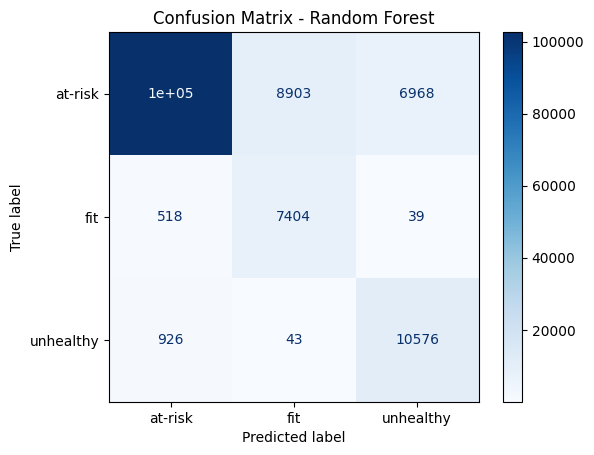

In [12]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

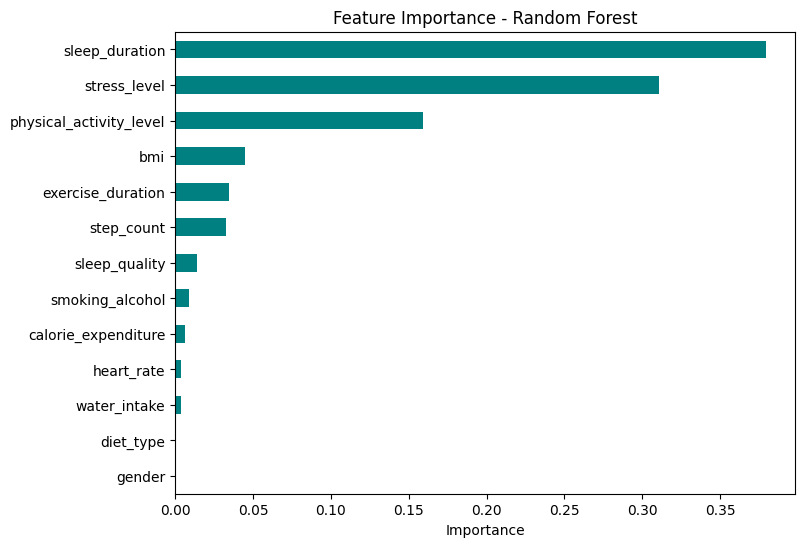

In [13]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

importances.plot(kind='barh', color='teal', figsize=(8,6))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()